In [ ]:
import pandas as pd
import os

# 1. Download the dataset directly (if it doesn't exist)
!wget -N https://raw.githubusercontent.com/gridflowai/gridflowAI-datasets-icons/master/AI-DATASETS/01-MISC/Heart_disease_cleveland_new.csv

# 2. Load the dataset
# We use just the filename because !wget saves it in the current folder
df = pd.read_csv("Heart_disease_cleveland_new.csv")

# 3. Display to confirm it works
print("Dataset Loaded Successfully!")
df.head(10)

--2026-02-07 15:41:40--  https://raw.githubusercontent.com/gridflowai/gridflowAI-datasets-icons/master/AI-DATASETS/01-MISC/Heart_disease_cleveland_new.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11024 (11K) [text/plain]
Saving to: ‘Heart_disease_cleveland_new.csv’

Heart_disease_cleve 100%[===================>]  10.77K  --.-KB/s    in 0s      

Last-modified header missing -- time-stamps turned off.
2026-02-07 15:41:40 (56.5 MB/s) - ‘Heart_disease_cleveland_new.csv’ saved [11024/11024]

Dataset Loaded Successfully!


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0
5,56,1,1,120,236,0,0,178,0,0.8,0,0,1,0
6,62,0,3,140,268,0,2,160,0,3.6,2,2,1,1
7,57,0,3,120,354,0,0,163,1,0.6,0,0,1,0
8,63,1,3,130,254,0,2,147,0,1.4,1,1,3,1
9,53,1,3,140,203,1,2,155,1,3.1,2,0,3,1


In [ ]:
import numpy as np

df = df.replace('?', np.nan)

df = df.dropna()

print(f"Dataset shape after correct cleaning: {df.shape}")

Dataset shape after correct cleaning: (303, 14)


In [ ]:
import pandas as pd

# List of categorical features based on the Cleveland dataset structure
categorical_features = ['cp', 'restecg', 'slope', 'thal']

# Apply One-Hot Encoding
df = pd.get_dummies(df, columns=categorical_features, drop_first=True)

print("Updated columns after One-Hot Encoding:")
print(df.columns)

Updated columns after One-Hot Encoding:
Index(['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak',
       'ca', 'target', 'cp_1', 'cp_2', 'cp_3', 'restecg_1', 'restecg_2',
       'slope_1', 'slope_2', 'thal_2', 'thal_3'],
      dtype='object')


In [ ]:
from sklearn.preprocessing import StandardScaler

# Define numerical columns to scale
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Initialize and apply StandardScaler
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Preview final preprocessed data
df.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,slope_1,slope_2,thal_2,thal_3
0,0.948726,1,0.757525,-0.264900,1,0.017197,0,1.087338,0,0,False,False,False,False,True,False,True,True,False
1,1.392002,1,1.611220,0.760415,0,-1.821905,1,0.397182,3,1,False,False,True,False,True,True,False,False,False
2,1.392002,1,-0.665300,-0.342283,0,-0.902354,1,1.346147,2,1,False,False,True,False,True,True,False,False,True
3,-1.932564,1,-0.096170,0.063974,0,1.637359,0,2.122573,0,0,False,True,False,False,False,False,True,False,False
4,-1.489288,0,-0.096170,-0.825922,0,0.980537,0,0.310912,0,0,True,False,False,False,True,False,False,False,False


Target Class Counts:
target
0    164
1    139
Name: count, dtype: int64


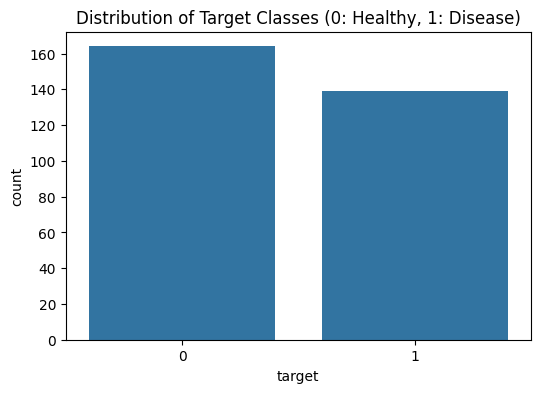

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check the distribution of the target variable
print("Target Class Counts:")
print(df['target'].value_counts())

# Visualize the balance
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df)
plt.title('Distribution of Target Classes (0: Healthy, 1: Disease)')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
import xgboost as xgb

# 1. Split the data
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Calculate scale_pos_weight (sum of negative / sum of positive)
# 164 / 139 = ~1.18
spw = 164 / 139

# 3. Train baseline model
baseline_model = xgb.XGBClassifier(scale_pos_weight=spw, random_state=42, eval_metric='logloss')
baseline_model.fit(X_train, y_train)
print("Baseline model trained.")

Baseline model trained.


In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the search space
param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 1.0]
}

# Run Grid Search
grid_search = GridSearchCV(estimator=baseline_model, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Use the best model found
best_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}


--- SIST 2026 Research Results ---
Final Accuracy: 0.8689
ROC-AUC Score: 0.9491

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.91      0.88        33
           1       0.88      0.82      0.85        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



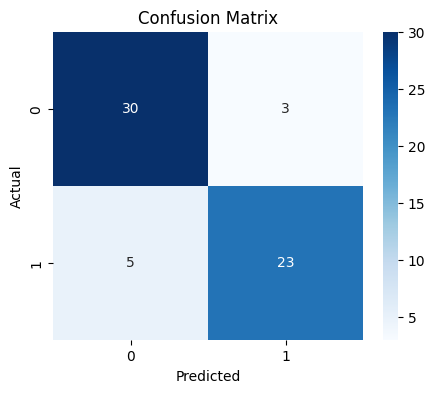

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Use the best model from your GridSearch
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("--- SIST 2026 Research Results ---")
print(f"Final Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix Visualization
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

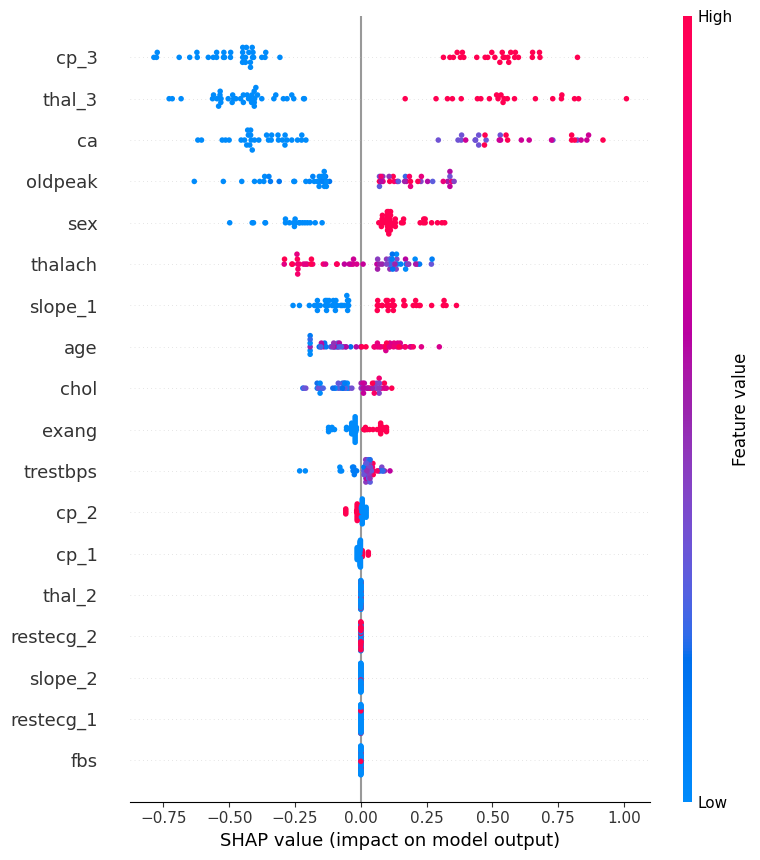

In [ ]:
import shap

# Initialize SHAP for the optimized XGBoost model
explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_test)

# Summary Plot (Beeswarm)
shap.summary_plot(shap_values, X_test)

Patient-specific diagnostic explanation:


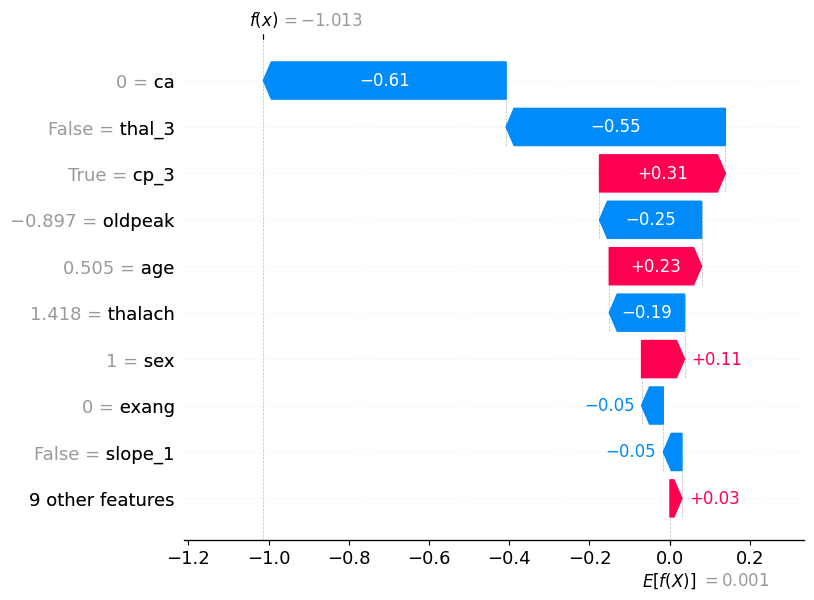

In [ ]:
# Explanation for the first patient in the test set
print("Patient-specific diagnostic explanation:")
shap.plots.waterfall(shap_values[0])

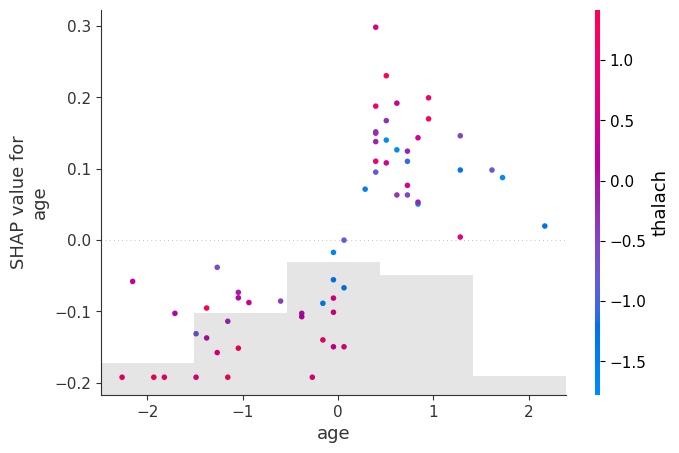

In [ ]:
# Dependence plot for age
shap.plots.scatter(shap_values[:,"age"], color=shap_values[:,"thalach"])

SHAP Summary for Women:


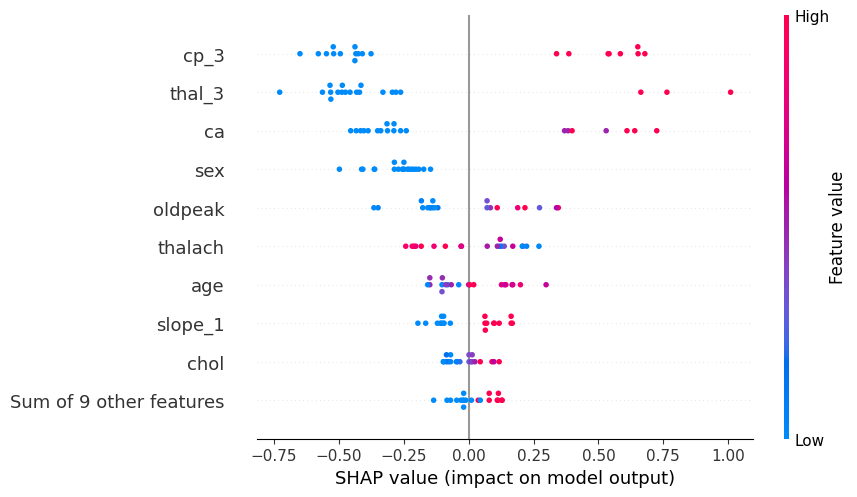

Recall at 0.5 threshold: 0.82
Recall at 0.3 threshold: 1.00 (Catching more sick people!)


In [ ]:
# 1. Gender Bias Check
X_test_female = X_test[X_test['sex'] == 0]
shap_values_female = explainer(X_test_female)
print("SHAP Summary for Women:")
shap.plots.beeswarm(shap_values_female)

# 2. Threshold Adjustment for Safety
# Let's see how many sick people we catch if we lower the bar to 30% probability
y_pred_safe = (y_prob > 0.3).astype(int)
from sklearn.metrics import recall_score
print(f"Recall at 0.5 threshold: {recall_score(y_test, y_pred):.2f}")
print(f"Recall at 0.3 threshold: {recall_score(y_test, y_pred_safe):.2f} (Catching more sick people!)")

SHAP Summary for Men:


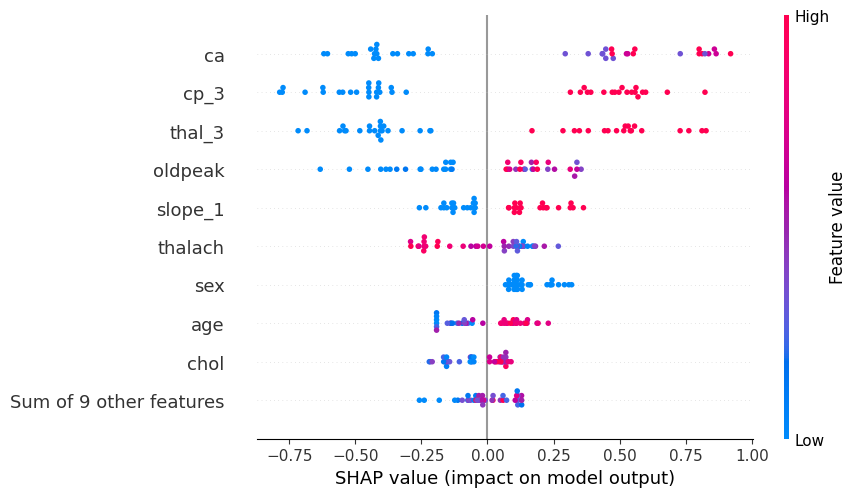

Recall at 0.5 threshold: 0.82
Recall at 0.3 threshold: 1.00 (Catching more sick people!)


In [ ]:
# 1. Gender Bias Check
X_test_male = X_test[X_test['sex'] == 1]
shap_values_male = explainer(X_test_male)
print("SHAP Summary for Men:")
shap.plots.beeswarm(shap_values_male)

# 2. Threshold Adjustment for Safety
# Let's see how many sick people we catch if we lower the bar to 30% probability
y_pred_safe = (y_prob > 0.3).astype(int)
from sklearn.metrics import recall_score
print(f"Recall at 0.5 threshold: {recall_score(y_test, y_pred):.2f}")
print(f"Recall at 0.3 threshold: {recall_score(y_test, y_pred_safe):.2f} (Catching more sick people!)")

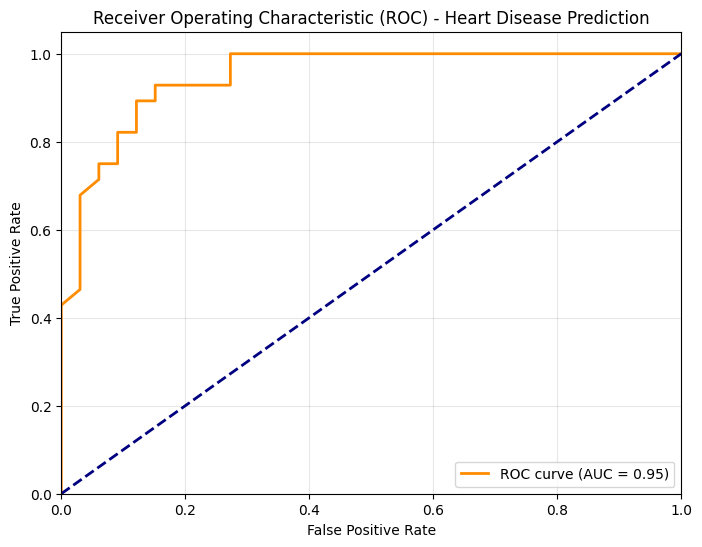

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curve data
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Random guess line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Heart Disease Prediction')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

Generating Plot: MALE Cohort...


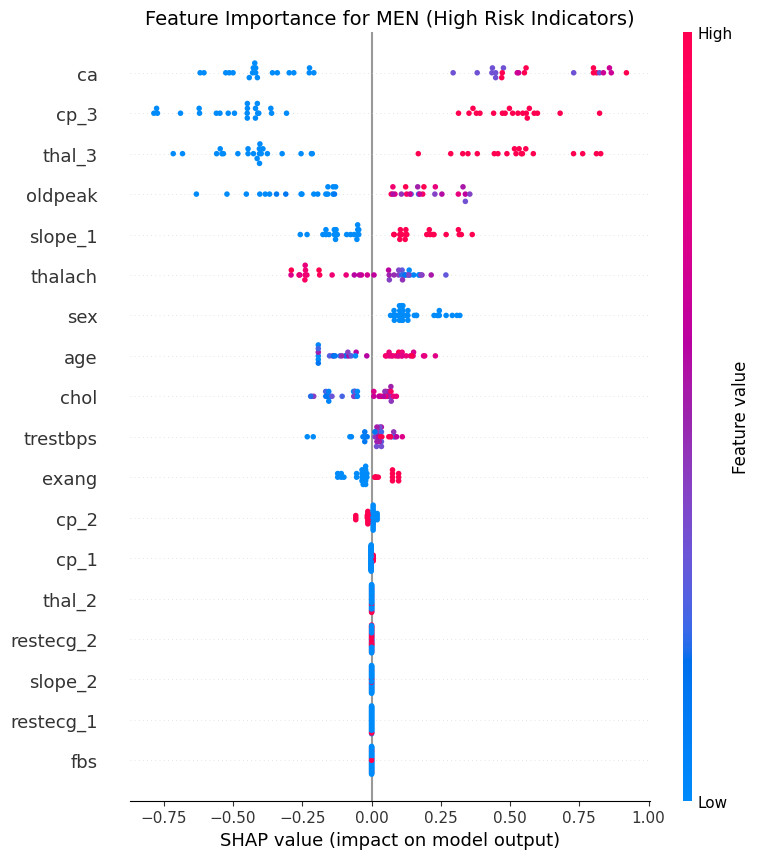

Generating Plot: FEMALE Cohort...


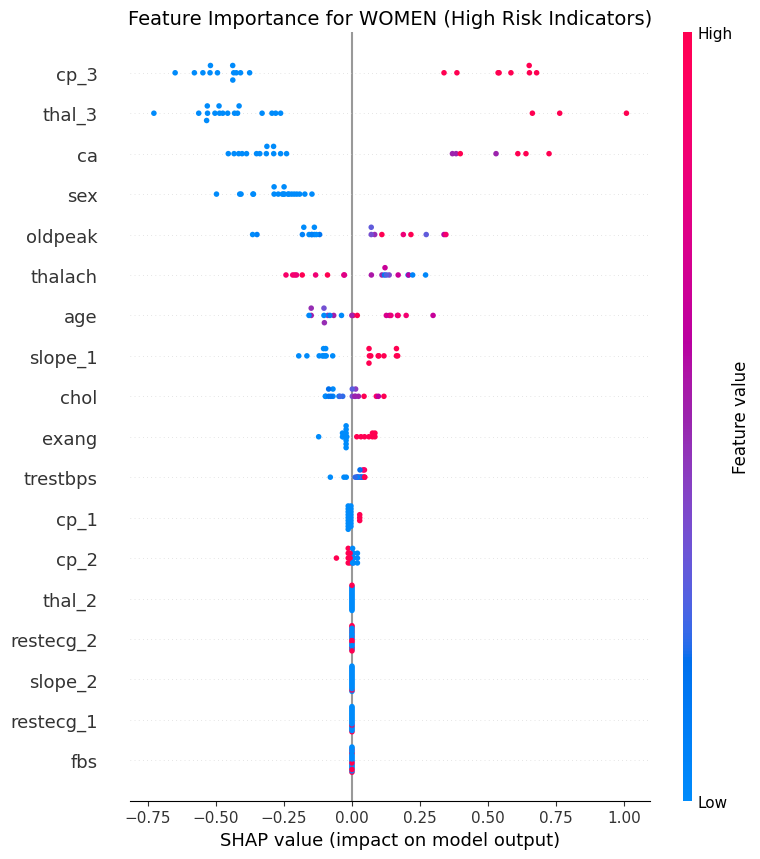

In [ ]:
import numpy as np
import shap
import matplotlib.pyplot as plt

# 1. Identify indices for Male and Female
# We use .values and flatten() to avoid the "ambiguous" Series error
male_indices = (X_test['sex'] == 1).values
female_indices = (X_test['sex'] == 0).values

# 2. Handle SHAP values structure
# If shap_values is a list (common for XGBoost), we take the values for the positive class [1]
if isinstance(shap_values, list):
    male_shap = shap_values[1][male_indices]
    female_shap = shap_values[1][female_indices]
else:
    # If it's a single array or Explanation object
    male_shap = shap_values[male_indices]
    female_shap = shap_values[female_indices]

# 3. Plot for MEN
print("Generating Plot: MALE Cohort...")
plt.figure(figsize=(10, 6))
shap.summary_plot(male_shap, X_test[male_indices], plot_type="dot", show=False)
plt.title("Feature Importance for MEN (High Risk Indicators)", fontsize=14)
plt.tight_layout()
plt.show()

# 4. Plot for WOMEN
print("Generating Plot: FEMALE Cohort...")
plt.figure(figsize=(10, 6))
shap.summary_plot(female_shap, X_test[female_indices], plot_type="dot", show=False)
plt.title("Feature Importance for WOMEN (High Risk Indicators)", fontsize=14)
plt.tight_layout()
plt.show()

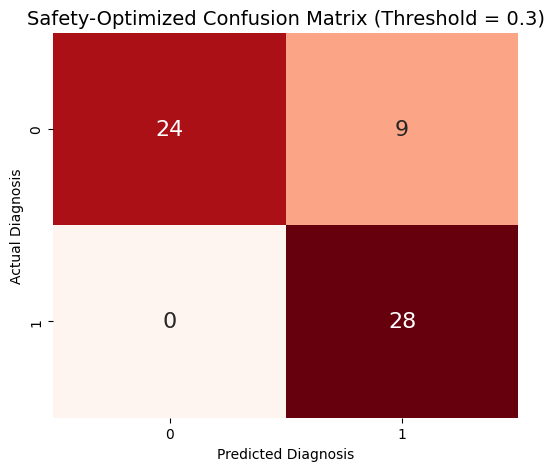

--- Performance at Threshold 0.3 ---
              precision    recall  f1-score   support

           0       1.00      0.73      0.84        33
           1       0.76      1.00      0.86        28

    accuracy                           0.85        61
   macro avg       0.88      0.86      0.85        61
weighted avg       0.89      0.85      0.85        61

False Negatives (Missed Cases): 0
SUCCESS: Zero-Miss achieved! (100% Recall)


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Define the Optimized Threshold
threshold_optimized = 0.3

# 2. Generate new predictions based on this threshold
y_pred_safe = (y_prob >= threshold_optimized).astype(int)

# 3. Plot the Safety-Optimized Confusion Matrix
cm_safe = confusion_matrix(y_test, y_pred_safe)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_safe, annot=True, fmt='d', cmap='Reds', cbar=False, annot_kws={"size": 16})
plt.title(f'Safety-Optimized Confusion Matrix (Threshold = {threshold_optimized})', fontsize=14)
plt.ylabel('Actual Diagnosis')
plt.xlabel('Predicted Diagnosis')
plt.show()

# 4. Print the metrics to confirm 100% Recall for your Table
print(f"--- Performance at Threshold {threshold_optimized} ---")
print(classification_report(y_test, y_pred_safe))

# Check specifically for False Negatives (bottom-left cell)
tn, fp, fn, tp = cm_safe.ravel()
print(f"False Negatives (Missed Cases): {fn}")
if fn == 0:
    print("SUCCESS: Zero-Miss achieved! (100% Recall)")

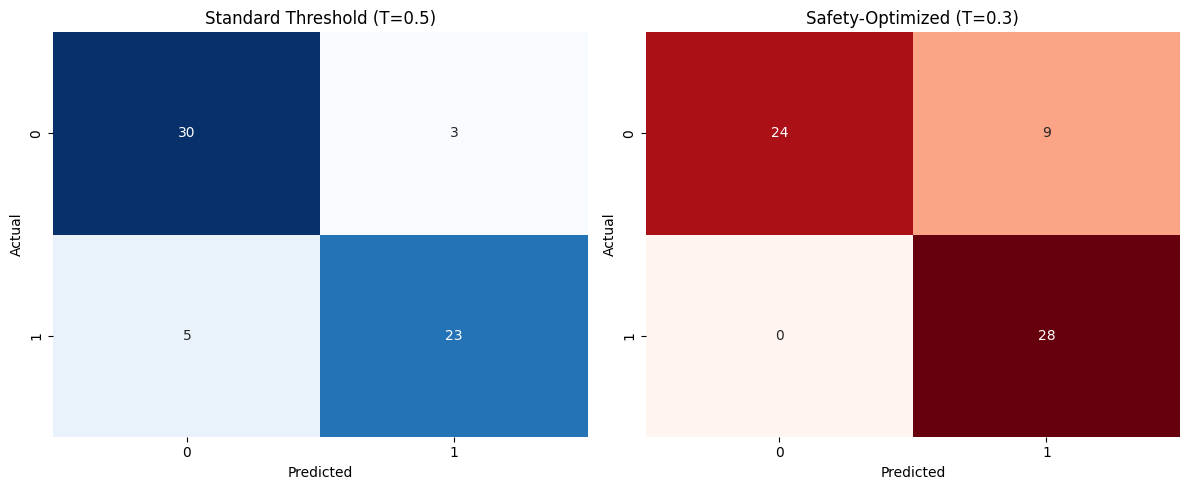

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# 1. Get predictions for both thresholds
y_pred_05 = (y_prob >= 0.5).astype(int)
y_pred_03 = (y_prob >= 0.3).astype(int)

# 2. Compute matrices
cm_05 = confusion_matrix(y_test, y_pred_05)
cm_03 = confusion_matrix(y_test, y_pred_03)

# 3. Plot side-by-side
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot 0.5
sns.heatmap(cm_05, annot=True, fmt='d', cmap='Blues', ax=ax[0], cbar=False)
ax[0].set_title('Standard Threshold (T=0.5)')
ax[0].set_ylabel('Actual')
ax[0].set_xlabel('Predicted')

# Plot 0.3
sns.heatmap(cm_03, annot=True, fmt='d', cmap='Reds', ax=ax[1], cbar=False)
ax[1].set_title('Safety-Optimized (T=0.3)')
ax[1].set_ylabel('Actual')
ax[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# 1. Define the thresholds to compare
thresholds = [0.5, 0.3]
results_data = []

print("--- PERFORMANCE COMPARISON ---")

for t in thresholds:
    # Convert probabilities to binary predictions based on threshold
    y_pred_current = (y_prob >= t).astype(int)

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred_current)
    prec = precision_score(y_test, y_pred_current)
    rec = recall_score(y_test, y_pred_current)
    f1 = f1_score(y_test, y_pred_current)

    # Store for the table (Fixed the syntax error here)
    results_data.append({
        'Threshold': t,
        'Accuracy': f"{acc:.2%}",
        'Precision': f"{prec:.2%}",
        'Recall': f"{rec:.2%}",
        'F1-Score': f"{f1:.2%}"
    })

# 2. Display as a clean Table for your paper
df_results = pd.DataFrame(results_data)
print("\n--- FINAL TABLE I DATA ---")
print(df_results.to_string(index=False))

--- PERFORMANCE COMPARISON ---

--- FINAL TABLE I DATA ---
 Threshold Accuracy Precision  Recall F1-Score
       0.5   86.89%    88.46%  82.14%   85.19%
       0.3   85.25%    75.68% 100.00%   86.15%
